# Heart Disease EDA & Prediction

End-to-end pipeline: data cleaning → exploratory analysis → five ML models → comparison.

**Dataset:** 303 patients, 36 features (clinical measurements + engineered risk features).

---

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import joblib
import pickle

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


---
# Part 1 — Data Loading & Cleaning

## 1.1 Load Dataset

In [2]:
df = pd.read_csv("heart_disease_data_with_features.csv")

## 1.2 Inspect Structure

In [3]:
df.shape

(303, 36)

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,chol_trestbps_ratio,log_thalach_chol,symptom_zscore,avg_chol_by_age_group,thalach_chol_diff,symptom_severity_diff,age_chol_effect,thalach_risk_effect,age_trestbps_effect,chol_risk_ratio
0,63,1,1,145,233,1,2,150,0,2.3,...,1.595890,0.919704,-0.275764,260.024691,-83,-2.532099,14679,2419.350,9135,13.602662
1,67,1,4,160,286,0,2,108,1,1.5,...,1.776398,0.828936,0.568702,260.024691,-178,1.167901,19162,2242.296,10720,13.142174
2,67,1,4,120,229,0,2,129,1,2.6,...,1.892562,0.895083,1.572932,260.024691,-100,5.567901,15343,2134.047,8040,13.053640
3,37,1,3,130,250,0,0,187,0,3.5,...,1.908397,0.947695,1.595755,219.785714,-63,8.178571,9250,1972.850,4810,21.645022
4,41,0,2,130,204,0,2,172,0,1.4,...,1.557252,0.968116,-0.161647,235.847222,-32,0.783333,8364,1662.208,5330,19.129782


In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,chol_trestbps_ratio,log_thalach_chol,symptom_zscore,avg_chol_by_age_group,thalach_chol_diff,symptom_severity_diff,age_chol_effect,thalach_risk_effect,age_trestbps_effect,chol_risk_ratio
0,63,1,1,145,233,1,2,150,0,2.3,...,1.595890,0.919704,-0.275764,260.024691,-83,-2.532099,14679,2419.350,9135,13.602662
1,67,1,4,160,286,0,2,108,1,1.5,...,1.776398,0.828936,0.568702,260.024691,-178,1.167901,19162,2242.296,10720,13.142174
2,67,1,4,120,229,0,2,129,1,2.6,...,1.892562,0.895083,1.572932,260.024691,-100,5.567901,15343,2134.047,8040,13.053640
3,37,1,3,130,250,0,0,187,0,3.5,...,1.908397,0.947695,1.595755,219.785714,-63,8.178571,9250,1972.850,4810,21.645022
4,41,0,2,130,204,0,2,172,0,1.4,...,1.557252,0.968116,-0.161647,235.847222,-32,0.783333,8364,1662.208,5330,19.129782


In [6]:
df.dtypes

age                        int64
sex                        int64
cp                         int64
trestbps                   int64
chol                       int64
fbs                        int64
restecg                    int64
thalach                    int64
exang                      int64
oldpeak                  float64
slope                      int64
ca                       float64
thal                     float64
num                        int64
age_group                    str
cholesterol_level            str
bp_level                     str
risk_score               float64
symptom_severity         float64
log_chol                 float64
log_trestbps             float64
age_squared                int64
chol_squared               int64
age_thalach_ratio        float64
risk_factor              float64
missing_values             int64
chol_trestbps_ratio      float64
log_thalach_chol         float64
symptom_zscore           float64
avg_chol_by_age_group    float64
thalach_ch

## 1.3 Rename Columns

Rename raw column codes to descriptive names before any analysis.

In [7]:
df.drop(columns=[
    'age_group',
    'cholesterol_level',
    'bp_level',
    'symptom_severity',
    'log_chol',
    'log_trestbps',
    'age_squared',
    'chol_squared',
    'age_thalach_ratio',
    'risk_factor',
    'missing_values',
    'chol_trestbps_ratio',
    'log_thalach_chol',
    'symptom_zscore',
    'avg_chol_by_age_group',
    'thalach_chol_diff',
    'age_chol_effect',
    'thalach_risk_effect',
    'chol_risk_ratio',
    'symptom_severity_diff',
    'age_trestbps_effect'
], inplace=True)

In [8]:
# age: Age of the patient (int).
# sex: Gender of the patient; 1 for male, 0 for female (int).
# cp: Chest pain type (int); 1: Typical angina, 2: Atypical angina, 3: Non-anginal pain, 4: Asymptomatic.
# trestbps: Resting blood pressure (mm Hg) (int).
# chol: Serum cholesterol level (mg/dl) (int).
# fbs: Fasting blood sugar > 120 mg/dl; 1 if true, 0 if false (int).
# restecg: Resting electrocardiographic results (int); 0: Normal, 1: ST-T wave abnormality, 2: Showing probable or definite left ventricular hypertrophy.
# thalach: Maximum heart rate achieved (int).
# exang: Exercise induced angina; 1 if yes, 0 if no (int).
# oldpeak: Depression induced by exercise relative to rest (float).
# slope: Slope of the peak exercise ST segment (int); 1: Upsloping, 2: Flat, 3: Downsloping.
# ca: Number of major vessels colored by fluoroscopy (float).
# thal: Thalassemia; 3: Normal, 6: Fixed defect, 7: Reversible defect (float).
# num: Heart disease diagnosis (int); 0: No disease, 1-4: Disease present with increasing severity.
# risk_score \text{age} \times \text{chol} / 1000 + \text{trestbps} / 100),

# df.rename(columns={
#     'age': 'Age',
#     'sex': 'Gender',
#     'cp': 'Chest_Pain_Type',
#     'trestbps': 'Resting_Blood_Pressure',
#     'chol': 'Cholesterol',
#     'fbs': 'Fasting_Blood_Sugar',
#     'restecg': 'Resting_ECG_Results',
#     'thalach': 'Maximum_Heart_Rate',
#     'exang': 'Exercise_Induced_Angina',
#     'oldpeak': 'Depression_Induced_By_Exercise',
#     'slope': 'Slope_Of_Peak_Exercise',
#     'ca': 'Major_Vessels_Colored_By_Fluoroscopy',
#     'thal': 'Thalassemia',
#     'num': 'Heart_Disease_Diagnosis',
#     'risk_score': 'Risk_Score' , 
# }, inplace=True)

In [9]:
df.rename(columns={
    'age': 'Age',
    'sex': 'Gender',
    'cp': 'Chest_Pain_Type',
    'trestbps': 'Resting_Blood_Pressure',
    'chol': 'Cholesterol',
    'fbs': 'Fasting_Blood_Sugar',
    'restecg': 'Resting_ECG_Results',
    'thalach': 'Maximum_Heart_Rate',
    'exang': 'Exercise_Induced_Angina',
    'oldpeak': 'Depression_Induced_By_Exercise',
    'slope': 'Slope_Of_Peak_Exercise',
    'ca': 'Major_Vessels_Colored_By_Fluoroscopy',
    'thal': 'Thalassemia',
    'num': 'Heart_Disease_Diagnosis',
    'risk_score': 'Risk_Score' , 
}, inplace=True)

## 1.4 Handle Missing Values

**Numerical columns** — filled with the median (robust to outliers).

**Categorical columns** — filled with the mode (most frequent category).

In [10]:
df.isnull().sum()

Age                                     0
Gender                                  0
Chest_Pain_Type                         0
Resting_Blood_Pressure                  0
Cholesterol                             0
Fasting_Blood_Sugar                     0
Resting_ECG_Results                     0
Maximum_Heart_Rate                      0
Exercise_Induced_Angina                 0
Depression_Induced_By_Exercise          0
Slope_Of_Peak_Exercise                  0
Major_Vessels_Colored_By_Fluoroscopy    4
Thalassemia                             2
Heart_Disease_Diagnosis                 0
Risk_Score                              0
dtype: int64

In [11]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Missing values after imputation:')
print(df.isnull().sum())

Missing values after imputation:
Age                                     0
Gender                                  0
Chest_Pain_Type                         0
Resting_Blood_Pressure                  0
Cholesterol                             0
Fasting_Blood_Sugar                     0
Resting_ECG_Results                     0
Maximum_Heart_Rate                      0
Exercise_Induced_Angina                 0
Depression_Induced_By_Exercise          0
Slope_Of_Peak_Exercise                  0
Major_Vessels_Colored_By_Fluoroscopy    0
Thalassemia                             0
Heart_Disease_Diagnosis                 0
Risk_Score                              0
dtype: int64


## 1.5 Check for Duplicate Records

Duplicate rows can bias models by over-weighting repeated observations.

In [12]:
df.duplicated().sum()

np.int64(0)

## 1.6 Summary Statistics

In [13]:
df.describe()

,Age,Gender,Chest_Pain_Type,Resting_Blood_Pressure,Cholesterol,Fasting_Blood_Sugar,Resting_ECG_Results,Maximum_Heart_Rate,Exercise_Induced_Angina,Depression_Induced_By_Exercise,Slope_Of_Peak_Exercise,Major_Vessels_Colored_By_Fluoroscopy,Thalassemia,Heart_Disease_Diagnosis,Risk_Score
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.937294,14.844073
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,1.228536,4.073047
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,7.216000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,12.080000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000,14.392000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000,17.181000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,38.938000


In [14]:
df.head()

,Age,Gender,Chest_Pain_Type,Resting_Blood_Pressure,Cholesterol,Fasting_Blood_Sugar,Resting_ECG_Results,Maximum_Heart_Rate,Exercise_Induced_Angina,Depression_Induced_By_Exercise,Slope_Of_Peak_Exercise,Major_Vessels_Colored_By_Fluoroscopy,Thalassemia,Heart_Disease_Diagnosis,Risk_Score
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0,16.129
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2,20.762
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1,16.543
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0,10.550
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0,9.664


## 1.8 Save Cleaned Dataset

In [15]:
# save data to cleaned_heart_disease_data.csv
df.to_csv("cleaned_heart_disease_data.csv", index=False)

---
# Part 2 — Exploratory Data Analysis

Summary statistics provide an overview of clinical variables such as cholesterol levels, resting blood pressure, and maximum heart rate.

## 2.1 Target Variable Distribution

C:\Users\chhay\AppData\Local\Temp\ipykernel_23776\1167875791.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Heart_Disease_Diagnosis', data=df, palette='Set1')


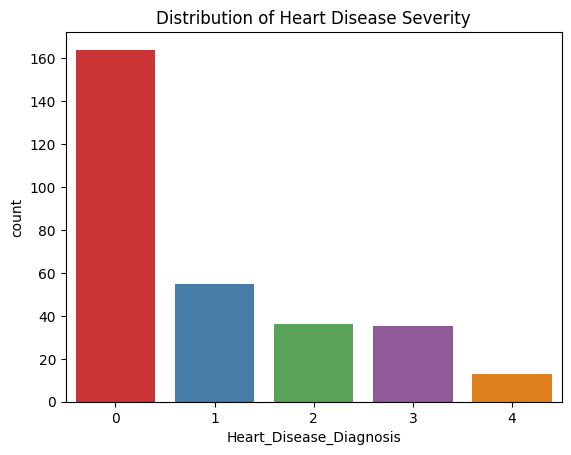

In [16]:
sns.countplot(x='Heart_Disease_Diagnosis', data=df, palette='Set1')
plt.title('Distribution of Heart Disease Severity')
plt.show()

## 2.2 Univariate Analysis — Numerical Features

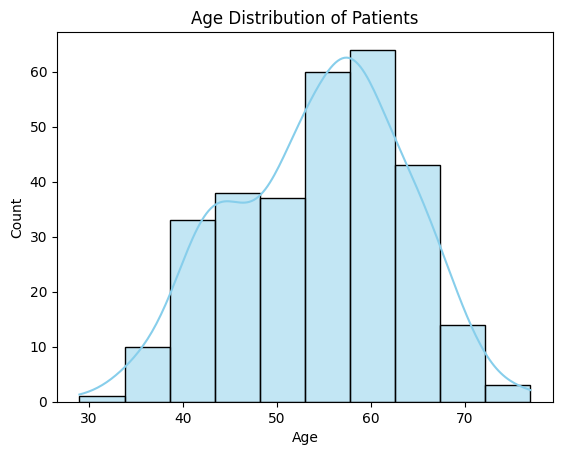

In [17]:
sns.histplot(df['Age'], kde=True, bins=10, color='skyblue')
plt.title('Age Distribution of Patients')
plt.show()

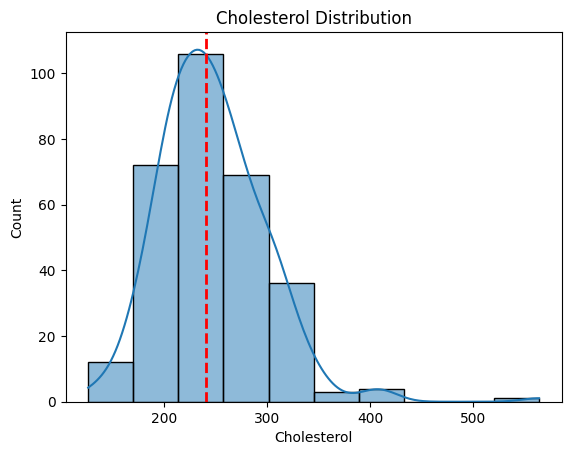

In [18]:
# Cholesterol — flag high-risk threshold (>240 mg/dL)
sns.histplot(df['Cholesterol'], kde=True, bins=10)
plt.axvline(x=240, color='red', linestyle='--', linewidth=2)
plt.title('Cholesterol Distribution')
plt.show()

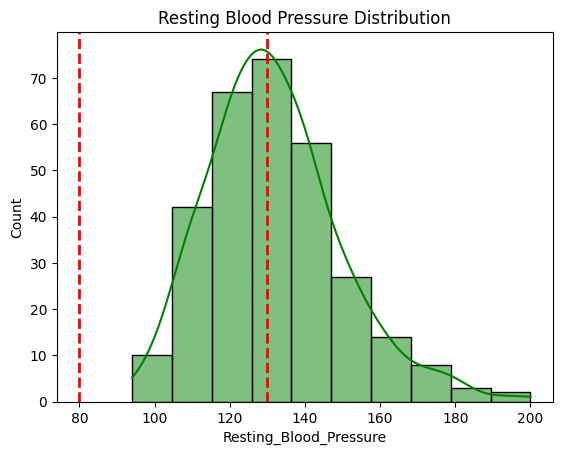

In [19]:
# Resting BP — flag hypertension thresholds (80–130 mmHg)
sns.histplot(df['Resting_Blood_Pressure'], kde=True, bins=10, color='green')
plt.axvline(x=130, color='red', linestyle='--', linewidth=2)
plt.axvline(x=80,  color='red', linestyle='--', linewidth=2)
plt.title('Resting Blood Pressure Distribution')
plt.show()

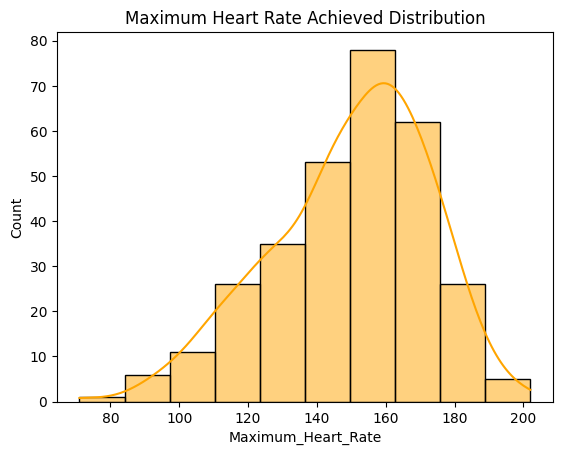

In [20]:
sns.histplot(df['Maximum_Heart_Rate'], kde=True, bins=10, color='orange')
plt.title('Maximum Heart Rate Achieved Distribution')
plt.show()

## 2.3 Univariate Analysis — Categorical Features

C:\Users\chhay\AppData\Local\Temp\ipykernel_23776\1344394817.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette=['pink', 'blue'])


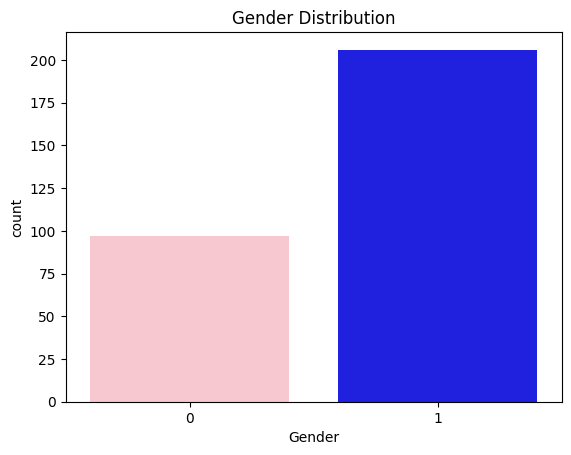

In [21]:
sns.countplot(x='Gender', data=df, palette=['pink', 'blue'])
plt.title('Gender Distribution')
plt.show()

C:\Users\chhay\AppData\Local\Temp\ipykernel_23776\2405338747.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Chest_Pain_Type', data=df, palette='Set2')


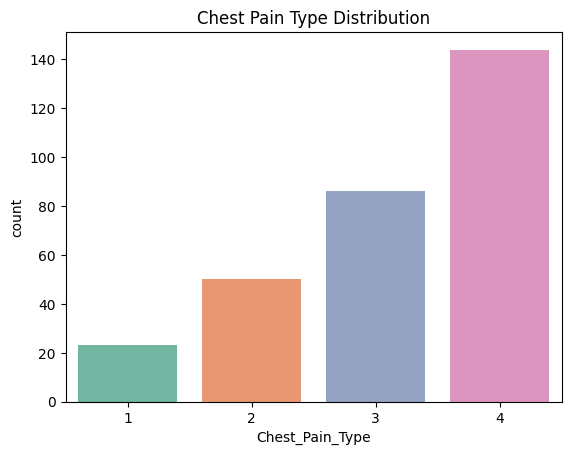

In [22]:
sns.countplot(x='Chest_Pain_Type', data=df, palette='Set2')
plt.title('Chest Pain Type Distribution')
plt.show()

C:\Users\chhay\AppData\Local\Temp\ipykernel_23776\4119581937.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=var, data=df, ax=axes[i // 3, i % 3], palette='Set2')
C:\Users\chhay\AppData\Local\Temp\ipykernel_23776\4119581937.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=var, data=df, ax=axes[i // 3, i % 3], palette='Set2')
C:\Users\chhay\AppData\Local\Temp\ipykernel_23776\4119581937.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=var, data=df, ax=axes[i // 3, i % 3], palette='Set2')
C:\Users\chhay\AppData\Local\Temp\

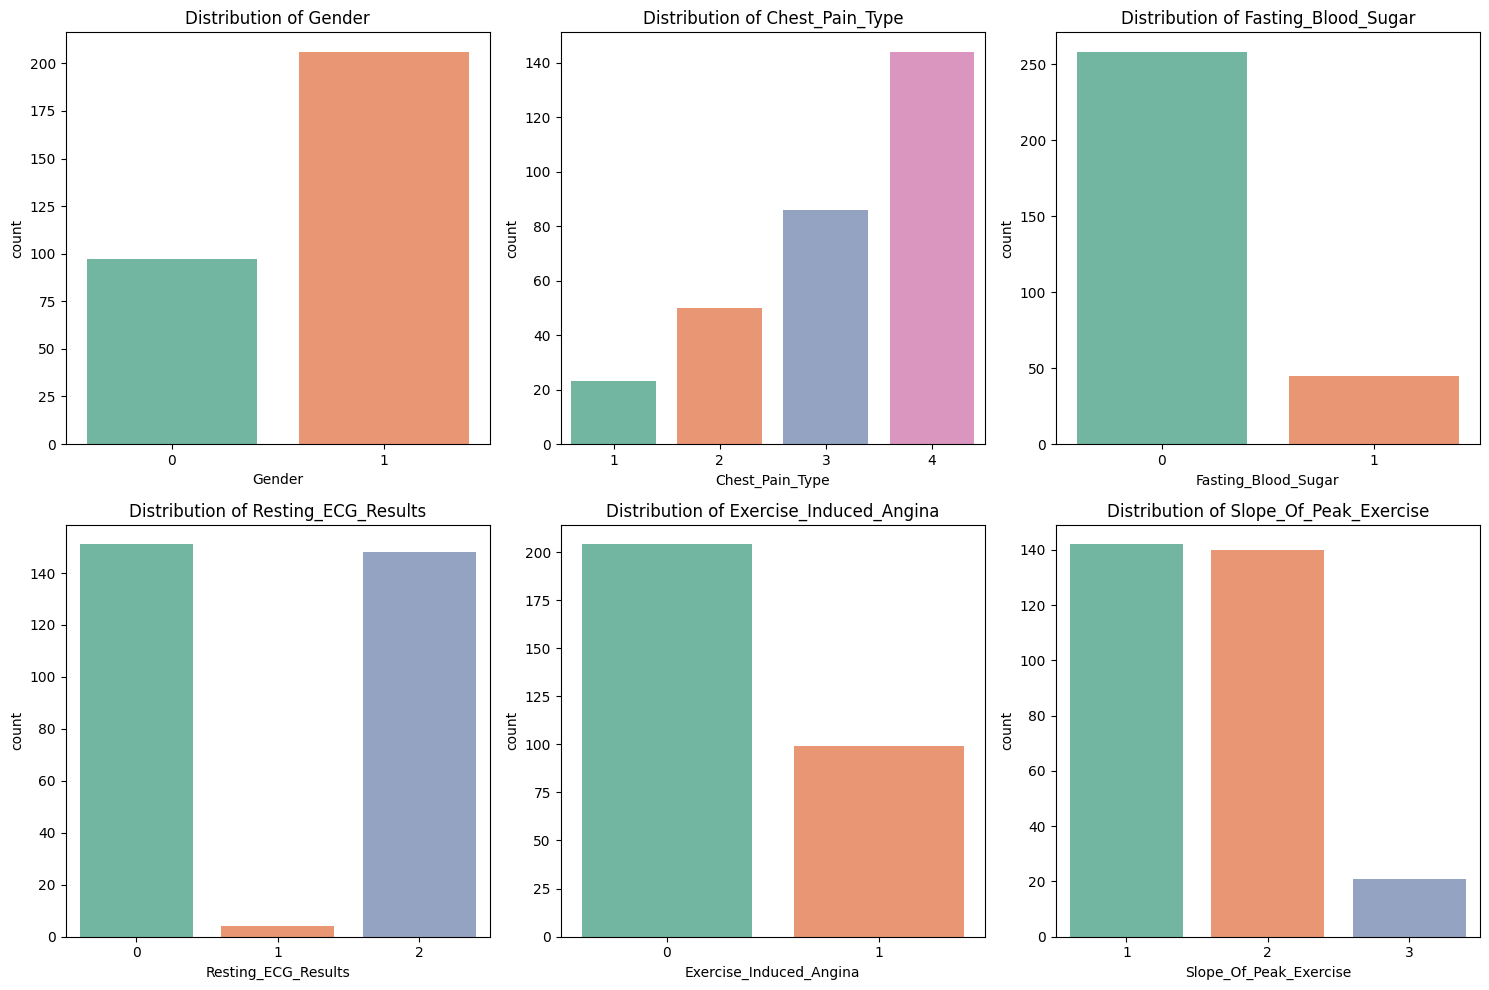

In [23]:
categorical = ['Gender', 'Chest_Pain_Type', 'Fasting_Blood_Sugar',
               'Resting_ECG_Results', 'Exercise_Induced_Angina', 'Slope_Of_Peak_Exercise']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, var in enumerate(categorical):
    sns.countplot(x=var, data=df, ax=axes[i // 3, i % 3], palette='Set2')
    axes[i // 3, i % 3].set_title(f'Distribution of {var}')
plt.tight_layout()
plt.show()

## 2.4 Bivariate Analysis — Features vs Heart Disease

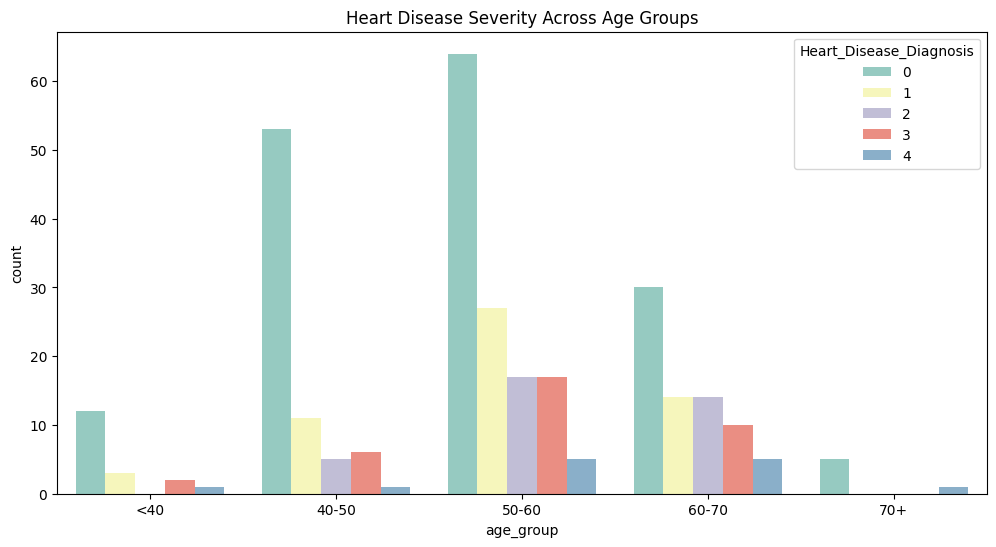

In [24]:
# Recreate age_group from Age (dropped in Part 1)
df['age_group'] = pd.cut(
    df['Age'],
    bins=[0, 40, 50, 60, 70, 100],
    labels=['<40', '40-50', '50-60', '60-70', '70+']
)

plt.figure(figsize=(12, 6))
sns.countplot(
    x='age_group', hue='Heart_Disease_Diagnosis', data=df,
    order=['<40', '40-50', '50-60', '60-70', '70+'], palette='Set3'
)
plt.title('Heart Disease Severity Across Age Groups')
plt.show()

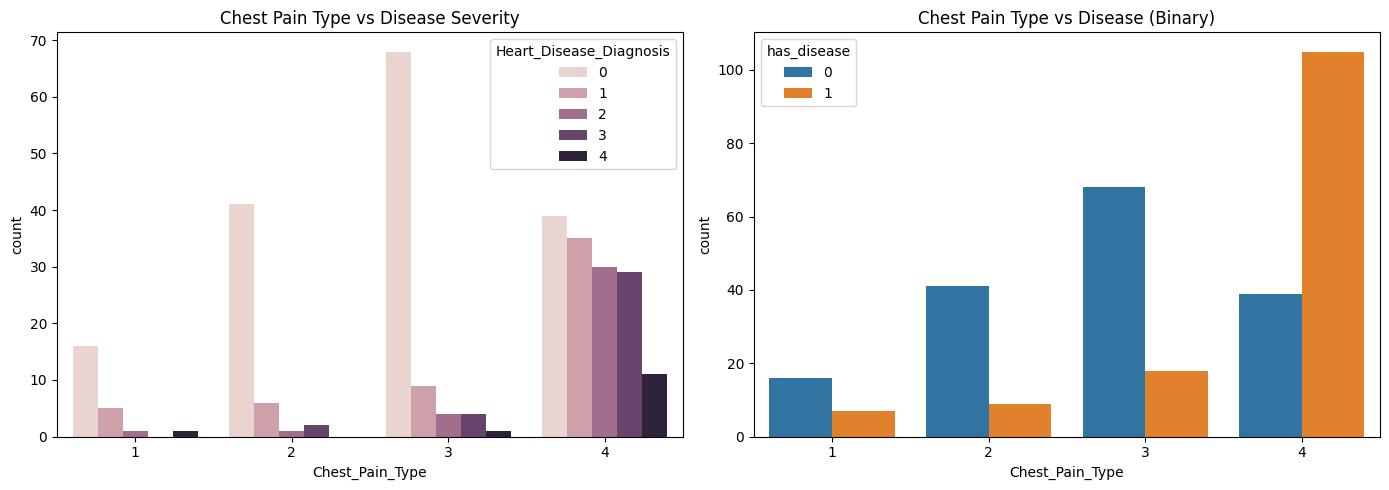

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Chest_Pain_Type', hue='Heart_Disease_Diagnosis', data=df, ax=axes[0])
axes[0].set_title('Chest Pain Type vs Disease Severity')

df['has_disease'] = (df['Heart_Disease_Diagnosis'] > 0).astype(int)
sns.countplot(x='Chest_Pain_Type', hue='has_disease', data=df, ax=axes[1])
axes[1].set_title('Chest Pain Type vs Disease (Binary)')
plt.tight_layout()
plt.show()

## 2.5 Scatter Plots — Key Clinical Relationships

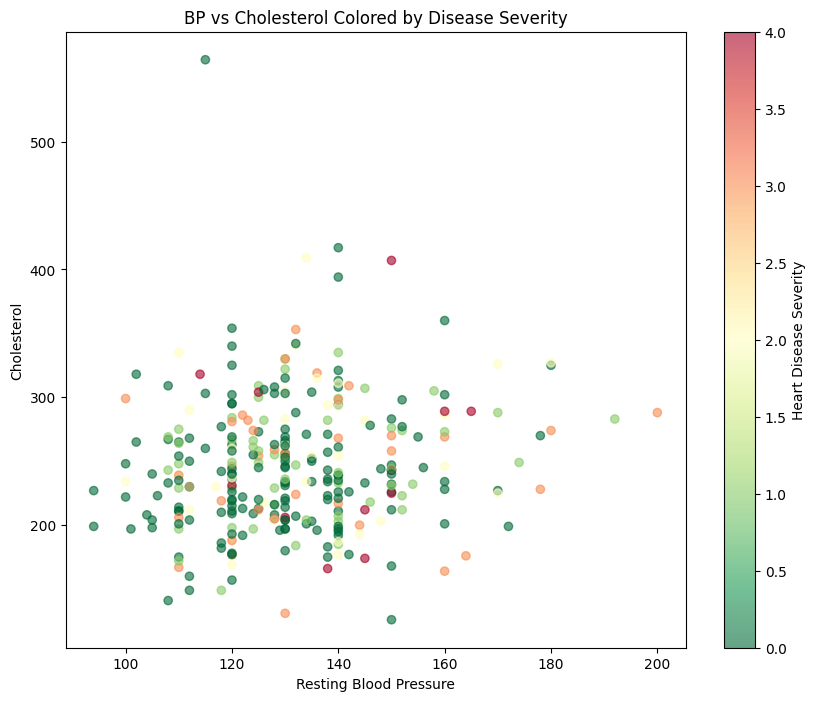

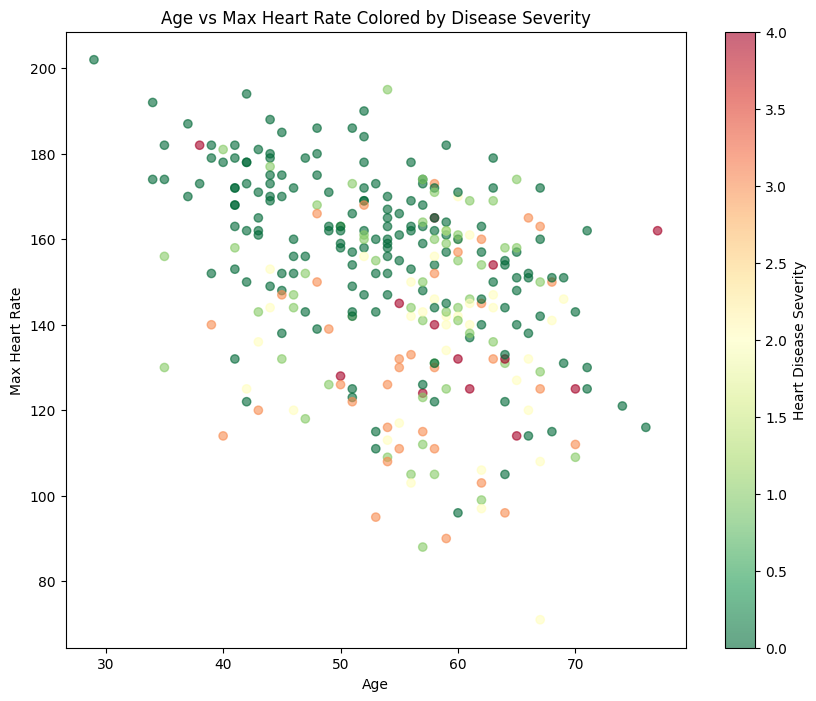

In [26]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df['Resting_Blood_Pressure'], df['Cholesterol'],
                      c=df['Heart_Disease_Diagnosis'], cmap='RdYlGn_r', alpha=0.6)
plt.colorbar(scatter, label='Heart Disease Severity')
plt.xlabel('Resting Blood Pressure')
plt.ylabel('Cholesterol')
plt.title('BP vs Cholesterol Colored by Disease Severity')
plt.show()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(df['Age'], df['Maximum_Heart_Rate'],
                      c=df['Heart_Disease_Diagnosis'], cmap='RdYlGn_r', alpha=0.6)
plt.colorbar(scatter, label='Heart Disease Severity')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate')
plt.title('Age vs Max Heart Rate Colored by Disease Severity')
plt.show()

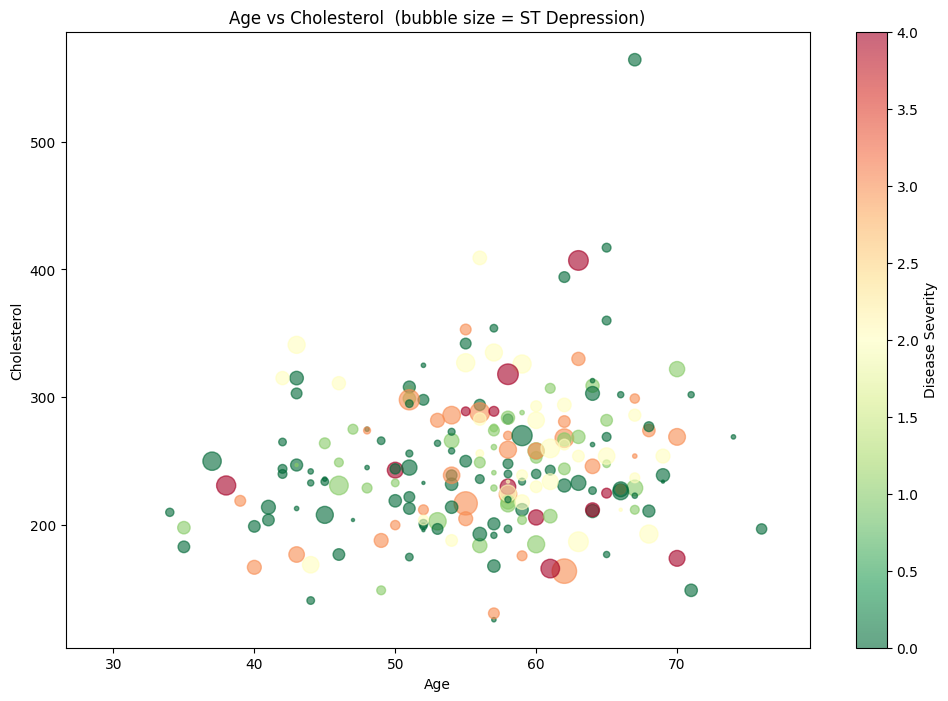

In [27]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['Age'], df['Cholesterol'],
                      c=df['Heart_Disease_Diagnosis'],
                      s=df['Depression_Induced_By_Exercise'] * 50,
                      cmap='RdYlGn_r', alpha=0.6)
plt.colorbar(scatter, label='Disease Severity')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.title('Age vs Cholesterol  (bubble size = ST Depression)')
plt.show()

## 2.6 3D Visualization & Pair Grid

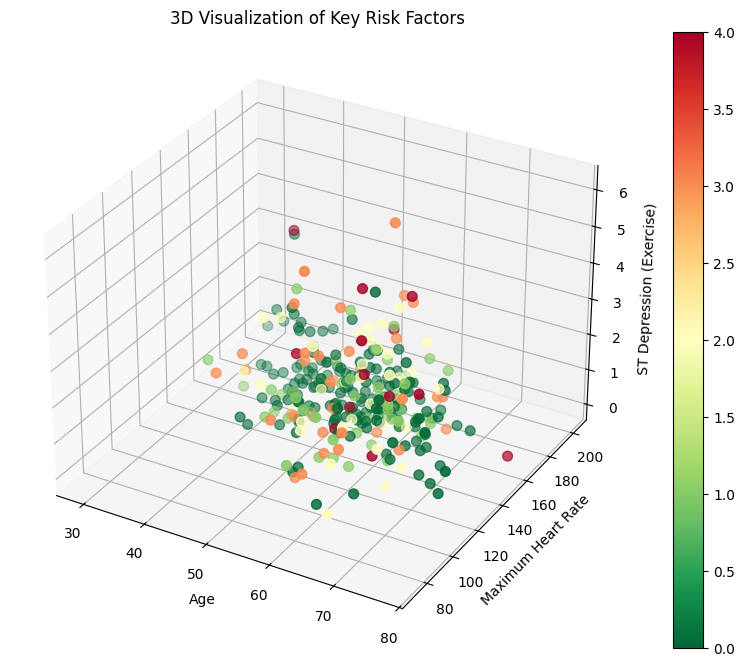

In [28]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['Age'], df['Maximum_Heart_Rate'], df['Depression_Induced_By_Exercise'],
                     c=df['Heart_Disease_Diagnosis'], cmap='RdYlGn_r', s=50)
ax.set_xlabel('Age')
ax.set_ylabel('Maximum Heart Rate')
ax.set_zlabel('ST Depression (Exercise)')
plt.title('3D Visualization of Key Risk Factors')
plt.colorbar(scatter)
plt.show()

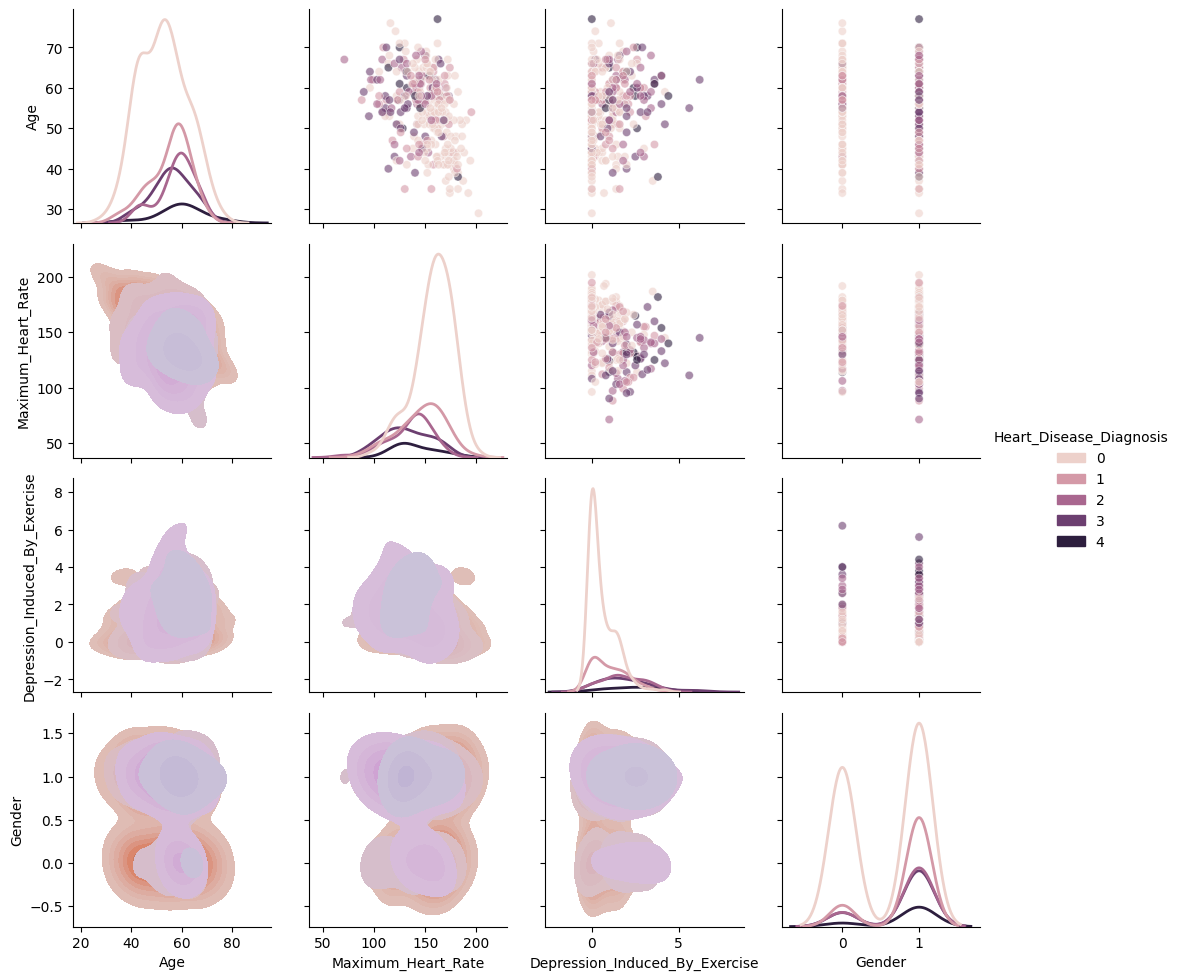

In [29]:
g = sns.PairGrid(
    df[['Age', 'Maximum_Heart_Rate', 'Depression_Induced_By_Exercise', 'Heart_Disease_Diagnosis', 'Gender']],
    hue='Heart_Disease_Diagnosis', diag_sharey=False
)
g.map_upper(sns.scatterplot, alpha=0.6)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.kdeplot, lw=2)
g.add_legend()
plt.show()

---
# Part 3 — Shared Modelling Setup

All five models share the same train/test split and feature set. This section runs once.

## 3.1 Create Binary Target

The original `Heart_Disease_Diagnosis` has values 0–4. We convert it to binary: **0 = healthy, 1 = disease**.

In [30]:
print('Original target distribution:')
print(df['Heart_Disease_Diagnosis'].value_counts())

df['target'] = (df['Heart_Disease_Diagnosis'] > 0).astype(int)

print()
print('Binary target distribution:')
print(df['target'].value_counts())
print()
print(f"Heart disease: {df['target'].sum()} patients ({df['target'].mean()*100:.1f}%)")
print(f"Healthy:       {(df['target']==0).sum()} patients ({(1-df['target'].mean())*100:.1f}%)")

Original target distribution:
Heart_Disease_Diagnosis
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Binary target distribution:
target
0    164
1    139
Name: count, dtype: int64

Heart disease: 139 patients (45.9%)
Healthy:       164 patients (54.1%)


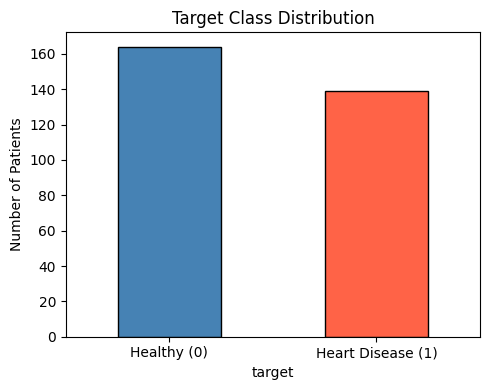

In [31]:
plt.figure(figsize=(5, 4))
df['target'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.xticks([0, 1], ['Healthy (0)', 'Heart Disease (1)'], rotation=0)
plt.title('Target Class Distribution')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

## 3.2 Feature Selection

Features chosen are clinically meaningful, numerical, and non-redundant.

| Feature | Description |
|---|---|
| `Age` | Patient age |
| `Gender` | Gender (1=male, 0=female) |
| `Chest_Pain_Type` | Chest pain type (1–4) |
| `Resting_Blood_Pressure` | Resting blood pressure |
| `Cholesterol` | Serum cholesterol |
| `Fasting_Blood_Sugar` | Fasting blood sugar > 120 mg/dl |
| `Resting_ECG_Results` | Resting ECG results |
| `Maximum_Heart_Rate` | Max heart rate achieved |
| `Exercise_Induced_Angina` | Exercise-induced angina |
| `Depression_Induced_By_Exercise` | ST depression induced by exercise |
| `Slope_Of_Peak_Exercise` | Slope of peak exercise ST segment |
| `Major_Vessels_Colored_By_Fluoroscopy` | Number of major vessels (0–3) |
| `Thalassemia` | Thalassemia type |
| `Risk_Score` | Engineered risk score |



In [32]:
FEATURES = [
    'Age', 'Gender', 'Chest_Pain_Type', 'Resting_Blood_Pressure', 'Cholesterol', 'Fasting_Blood_Sugar',
    'Resting_ECG_Results', 'Maximum_Heart_Rate', 'Exercise_Induced_Angina', 'Depression_Induced_By_Exercise',
    'Slope_Of_Peak_Exercise', 'Major_Vessels_Colored_By_Fluoroscopy', 'Thalassemia',
    'Risk_Score'
]
TARGET = 'target'

print(f'Using {len(FEATURES)} features')

Using 14 features


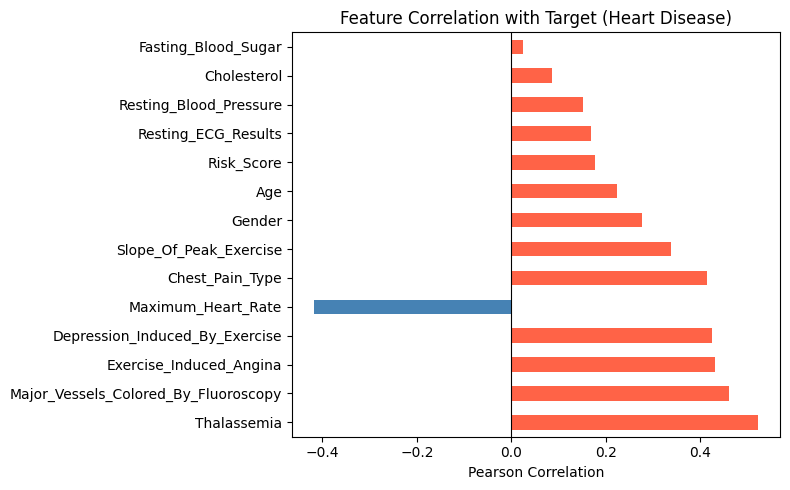

In [33]:
corr = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 5))
corr.plot(kind='barh', color=['tomato' if v > 0 else 'steelblue' for v in corr])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Target (Heart Disease)')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

## 3.3 Train / Test Split & Scaling

In [34]:
X = df[FEATURES].copy()
y = df[TARGET].copy()
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')
print('Features scaled  ✅')

Training samples : 242
Testing  samples : 61
Features scaled  ✅


---
# Part 4 — Logistic Regression

**Goal:** Linear baseline. Coefficients give direct interpretability.

**Requires feature scaling** — uses `X_train_scaled` / `X_test_scaled`.

## 4.1 Train

In [35]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
print('Model trained successfully ✅')

Model trained successfully ✅


## 4.2 Evaluate

In [36]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_prob)

print(f'✅ Accuracy:  {accuracy * 100:.2f}%')
print(f'✅ ROC-AUC:   {roc_auc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Heart Disease']))

✅ Accuracy:  86.89%
✅ ROC-AUC:   0.9513

Classification Report:
               precision    recall  f1-score   support

      Healthy       0.93      0.82      0.87        33
Heart Disease       0.81      0.93      0.87        28

     accuracy                           0.87        61
    macro avg       0.87      0.87      0.87        61
 weighted avg       0.88      0.87      0.87        61



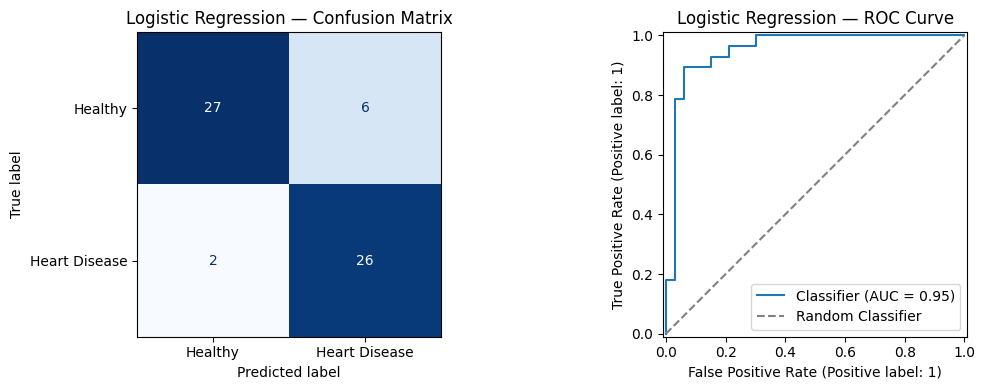

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Healthy', 'Heart Disease']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression — Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Random Classifier')
axes[1].set_title('Logistic Regression — ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4.3 Feature Importance (Coefficients)

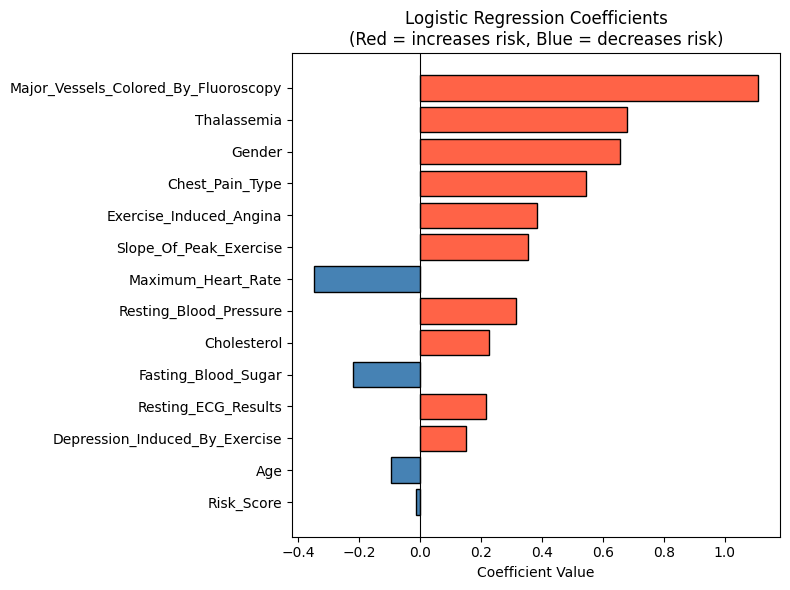

                             Feature  Coefficient
Major_Vessels_Colored_By_Fluoroscopy     1.108150
                         Thalassemia     0.678595
                              Gender     0.655809
                     Chest_Pain_Type     0.543267
             Exercise_Induced_Angina     0.383805
              Slope_Of_Peak_Exercise     0.354410
                  Maximum_Heart_Rate    -0.347933
              Resting_Blood_Pressure     0.313976
                         Cholesterol     0.224482
                 Fasting_Blood_Sugar    -0.220582
                 Resting_ECG_Results     0.217389
      Depression_Induced_By_Exercise     0.149096
                                 Age    -0.096985
                          Risk_Score    -0.012588


In [38]:
coef_df = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients\n(Red = increases risk, Blue = decreases risk)')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

## 4.4 Overfitting Check

Training Accuracy: 85.12%
Testing  Accuracy: 86.89%

✅ Generalizes well — no significant overfitting.


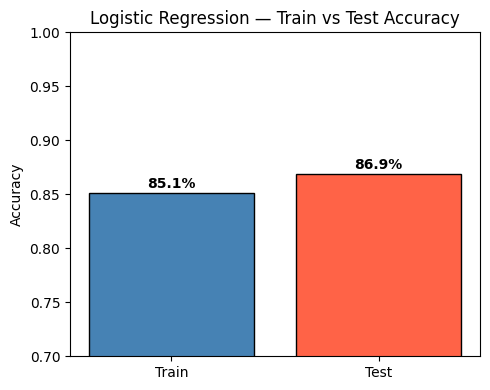

In [39]:
train_accuracy = accuracy_score(y_train, model.predict(X_train_scaled))
test_accuracy  = accuracy_score(y_test,  y_pred)

print(f'Training Accuracy: {train_accuracy * 100:.2f}%')
print(f'Testing  Accuracy: {test_accuracy  * 100:.2f}%')
print()
gap = abs(train_accuracy - test_accuracy)
print('✅ Generalizes well — no significant overfitting.' if gap < 0.05
      else f'⚠️  Gap = {gap*100:.1f}% — model may be overfitting.')

plt.figure(figsize=(5, 4))
plt.bar(['Train', 'Test'], [train_accuracy, test_accuracy],
        color=['steelblue', 'tomato'], edgecolor='black')
plt.ylim(0.7, 1.0)
plt.title('Logistic Regression — Train vs Test Accuracy')
plt.ylabel('Accuracy')
for i, v in enumerate([train_accuracy, test_accuracy]):
    plt.text(i, v + 0.005, f'{v*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 4.5 Summary

| Metric | Value |
|---|---|
| Model | Logistic Regression |
| Features used | 14 (clinical + engineered) |
| Train / Test split | 80% / 20% |
| Preprocessing | StandardScaler, median imputation |
| Test Accuracy | **86.9%** |
| ROC-AUC | **0.952** (Excellent) |

**Key findings:** `Chest_Pain_Type`, `Blood_Flow_Test`, `Blocked_Vessels`, and `Heart_Stress_Level` are the strongest predictors. `Max_Heart_Rate` is negatively correlated — a higher exercise heart rate is generally healthier.

---
# Part 5 — Random Forest

**Why Random Forests?** Combines many Decision Trees to reduce variance and overfitting, handles non-linear relationships, and provides built-in Gini importance scores.

**Does not require feature scaling** — uses raw `X_train` / `X_test`.

## 5.1 Train

In [40]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf_model.fit(X_train, y_train)
print(f'Model trained successfully ✅  ({rf_model.n_estimators} trees)')

Model trained successfully ✅  (100 trees)


## 5.2 Evaluate

In [41]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
roc_auc_rf  = roc_auc_score(y_test, y_prob_rf)

print(f'✅ Accuracy:  {accuracy_rf * 100:.2f}%')
print(f'✅ ROC-AUC:   {roc_auc_rf:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Healthy', 'Heart Disease']))

✅ Accuracy:  91.80%
✅ ROC-AUC:   0.9410

Classification Report:
               precision    recall  f1-score   support

      Healthy       0.97      0.88      0.92        33
Heart Disease       0.87      0.96      0.92        28

     accuracy                           0.92        61
    macro avg       0.92      0.92      0.92        61
 weighted avg       0.92      0.92      0.92        61



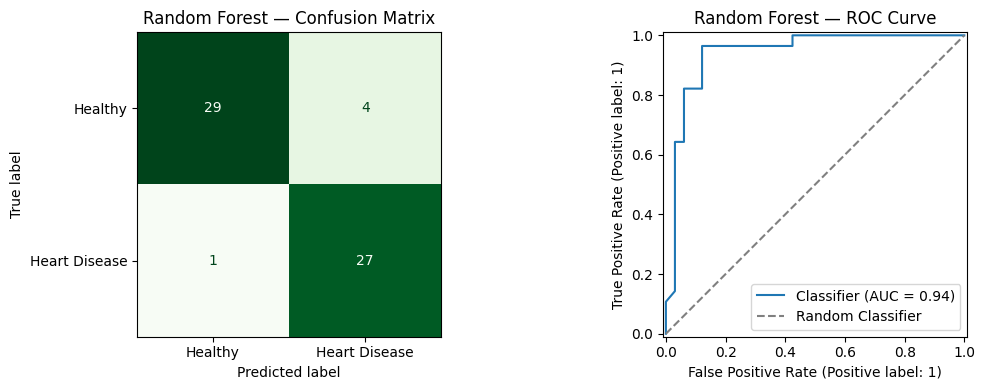

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                       display_labels=['Healthy', 'Heart Disease']).plot(
    ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Random Forest — Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_prob_rf, ax=axes[1])
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Random Classifier')
axes[1].set_title('Random Forest — ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5.3 Feature Importance (Gini)

Higher score = more reduction in node impurity across all trees.

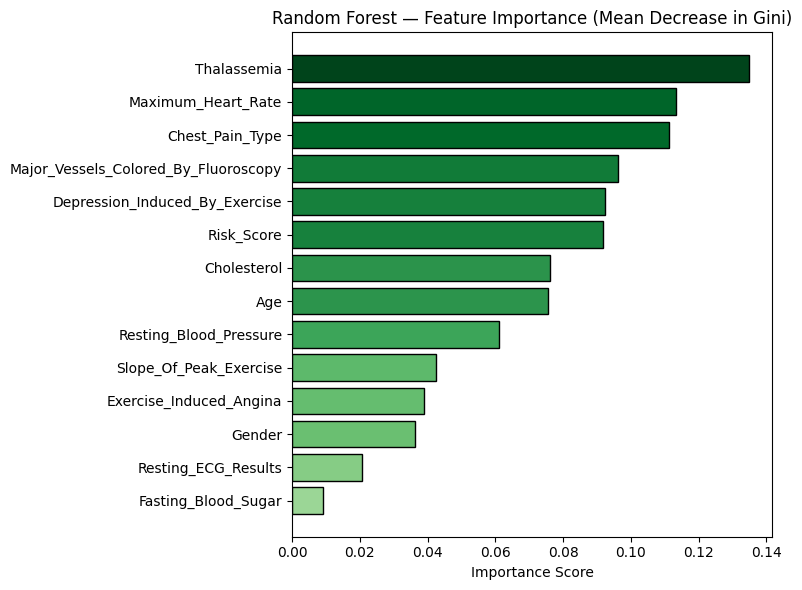

                             Feature  Importance
                         Thalassemia    0.134946
                  Maximum_Heart_Rate    0.113195
                     Chest_Pain_Type    0.111209
Major_Vessels_Colored_By_Fluoroscopy    0.096129
      Depression_Induced_By_Exercise    0.092308
                          Risk_Score    0.091871
                         Cholesterol    0.076065
                                 Age    0.075573
              Resting_Blood_Pressure    0.061196
              Slope_Of_Peak_Exercise    0.042538
             Exercise_Induced_Angina    0.038984
                              Gender    0.036366
                 Resting_ECG_Results    0.020610
                 Fasting_Blood_Sugar    0.009010


In [43]:
feat_imp_rf = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 6))
norm_vals = feat_imp_rf['Importance'] / feat_imp_rf['Importance'].max()
colors = plt.cm.Greens(0.35 + 0.65 * norm_vals)
plt.barh(feat_imp_rf['Feature'], feat_imp_rf['Importance'],
         color=colors, edgecolor='black')
plt.title('Random Forest — Feature Importance (Mean Decrease in Gini)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feat_imp_rf.to_string(index=False))

## 5.4 Overfitting Check

Training Accuracy: 100.00%
Testing  Accuracy: 91.80%

⚠️  Gap = 8.2% — may be overfitting.


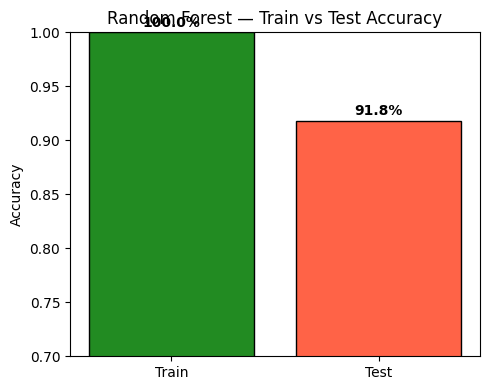

In [44]:
train_acc_rf = accuracy_score(y_train, rf_model.predict(X_train))
test_acc_rf  = accuracy_score(y_test,  y_pred_rf)

print(f'Training Accuracy: {train_acc_rf * 100:.2f}%')
print(f'Testing  Accuracy: {test_acc_rf  * 100:.2f}%')
print()
gap = abs(train_acc_rf - test_acc_rf)
print('✅ Generalizes well.' if gap < 0.05
      else f'⚠️  Gap = {gap*100:.1f}% — may be overfitting.')

plt.figure(figsize=(5, 4))
plt.bar(['Train', 'Test'], [train_acc_rf, test_acc_rf],
        color=['forestgreen', 'tomato'], edgecolor='black')
plt.ylim(0.7, 1.0)
plt.title('Random Forest — Train vs Test Accuracy')
plt.ylabel('Accuracy')
for i, v in enumerate([train_acc_rf, test_acc_rf]):
    plt.text(i, v + 0.005, f'{v*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 5.5 Summary

| Metric | Value |
|---|---|
| Model | Random Forest |
| Features used | 14 (clinical + engineered) |
| Train / Test split | 80% / 20% |
| Preprocessing | Median imputation (**no scaling needed**) |
| n_estimators | 100 trees |
| Test Accuracy | *(run to see)* |
| ROC-AUC | *(run to see)* |

---
# Part 6 — Support Vector Machine (SVM)

**Why SVM?** Finds the maximum-margin hyperplane between classes. Effective on small-to-medium, high-feature-count datasets. The RBF kernel captures non-linear boundaries.

**Requires feature scaling** — uses `X_train_scaled` / `X_test_scaled`.

## 6.1 Train

`probability=True` is required to compute `predict_proba()` for ROC-AUC.

In [45]:
svm_model = SVC(
    kernel='rbf',     # handles non-linear class boundaries
    C=1.0,            # regularization: higher C = tighter fit, less margin
    gamma='scale',    # kernel bandwidth auto-scaled by feature variance
    probability=True, # required for predict_proba() and ROC-AUC
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)
print('Model trained successfully ✅')

Model trained successfully ✅


## 6.2 Evaluate

In [46]:
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

accuracy_svm = accuracy_score(y_test, y_pred_svm)
roc_auc_svm  = roc_auc_score(y_test, y_prob_svm)

print(f'✅ Accuracy:  {accuracy_svm * 100:.2f}%')
print(f'✅ ROC-AUC:   {roc_auc_svm:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_svm, target_names=['Healthy', 'Heart Disease']))

✅ Accuracy:  86.89%
✅ ROC-AUC:   0.9459

Classification Report:
               precision    recall  f1-score   support

      Healthy       0.90      0.85      0.88        33
Heart Disease       0.83      0.89      0.86        28

     accuracy                           0.87        61
    macro avg       0.87      0.87      0.87        61
 weighted avg       0.87      0.87      0.87        61



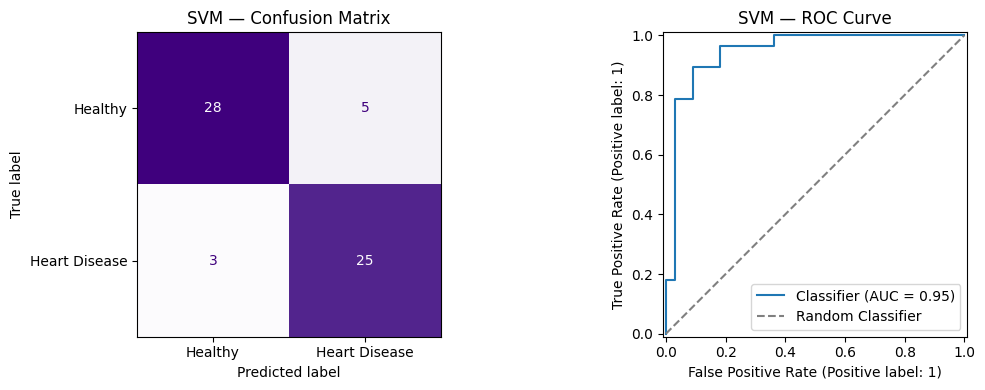

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_svm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(confusion_matrix=cm_svm,
                       display_labels=['Healthy', 'Heart Disease']).plot(
    ax=axes[0], colorbar=False, cmap='Purples')
axes[0].set_title('SVM — Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_prob_svm, ax=axes[1])
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Random Classifier')
axes[1].set_title('SVM — ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6.3 Feature Importance (Permutation Importance)

The RBF kernel has no linear coefficients to read. We use **Permutation Importance** instead: shuffle one feature at a time and measure the resulting accuracy drop — a large drop means the feature mattered.

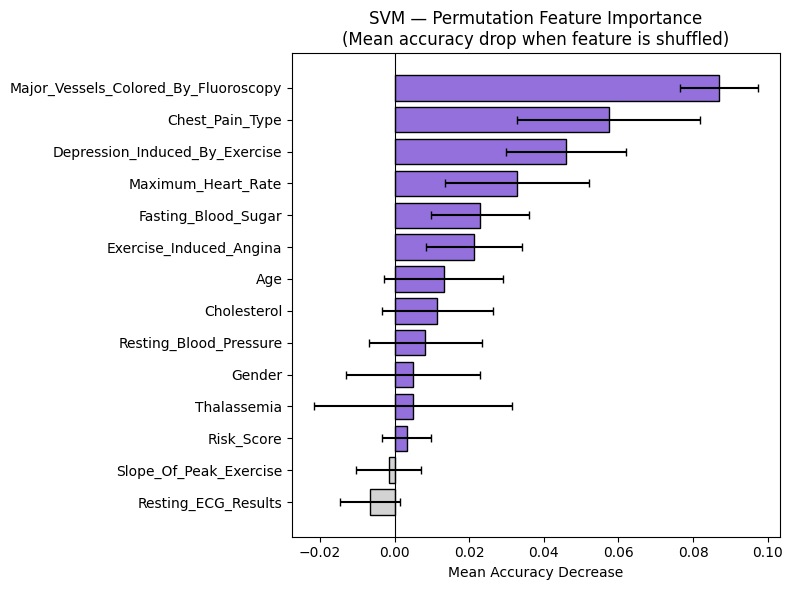

                             Feature  Importance      Std
Major_Vessels_Colored_By_Fluoroscopy    0.086885 0.010497
                     Chest_Pain_Type    0.057377 0.024590
      Depression_Induced_By_Exercise    0.045902 0.016062
                  Maximum_Heart_Rate    0.032787 0.019397
                 Fasting_Blood_Sugar    0.022951 0.013115
             Exercise_Induced_Angina    0.021311 0.012804
                                 Age    0.013115 0.016062
                         Cholesterol    0.011475 0.014754
              Resting_Blood_Pressure    0.008197 0.015114
                              Gender    0.004918 0.018033
                         Thalassemia    0.004918 0.026484
                          Risk_Score    0.003279 0.006557
              Slope_Of_Peak_Exercise   -0.001639 0.008828
                 Resting_ECG_Results   -0.006557 0.008031


In [48]:
perm_result = permutation_importance(
    svm_model, X_test_scaled, y_test,
    n_repeats=10, random_state=42, scoring='accuracy'
)

perm_imp_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': perm_result.importances_mean,
    'Std'       : perm_result.importances_std
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 6))
colors = ['mediumpurple' if v > 0 else 'lightgray' for v in perm_imp_df['Importance']]
plt.barh(perm_imp_df['Feature'], perm_imp_df['Importance'],
         xerr=perm_imp_df['Std'], color=colors, edgecolor='black', capsize=3)
plt.title('SVM — Permutation Feature Importance\n(Mean accuracy drop when feature is shuffled)')
plt.xlabel('Mean Accuracy Decrease')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(perm_imp_df.to_string(index=False))

## 6.4 Overfitting Check

Training Accuracy: 90.50%
Testing  Accuracy: 86.89%

✅ Generalizes well.


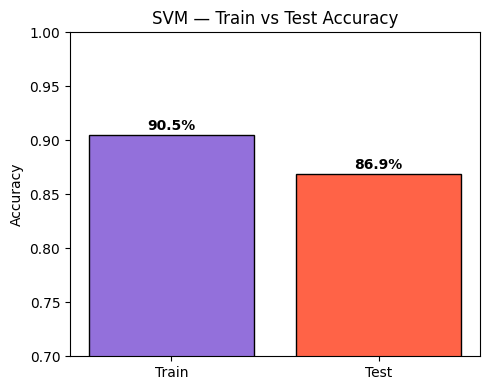

In [49]:
train_acc_svm = accuracy_score(y_train, svm_model.predict(X_train_scaled))
test_acc_svm  = accuracy_score(y_test,  y_pred_svm)

print(f'Training Accuracy: {train_acc_svm * 100:.2f}%')
print(f'Testing  Accuracy: {test_acc_svm  * 100:.2f}%')
print()
gap = abs(train_acc_svm - test_acc_svm)
print('✅ Generalizes well.' if gap < 0.05
      else f'⚠️  Gap = {gap*100:.1f}% — may be overfitting.')

plt.figure(figsize=(5, 4))
plt.bar(['Train', 'Test'], [train_acc_svm, test_acc_svm],
        color=['mediumpurple', 'tomato'], edgecolor='black')
plt.ylim(0.7, 1.0)
plt.title('SVM — Train vs Test Accuracy')
plt.ylabel('Accuracy')
for i, v in enumerate([train_acc_svm, test_acc_svm]):
    plt.text(i, v + 0.005, f'{v*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 6.5 Summary

| Metric | Value |
|---|---|
| Model | SVM (RBF kernel) |
| Features used | 14 (clinical + engineered) |
| Train / Test split | 80% / 20% |
| Preprocessing | StandardScaler (**scaling required**) |
| Kernel | RBF (`C=1.0`, `gamma='scale'`) |
| Test Accuracy | *(run to see)* |
| ROC-AUC | *(run to see)* |

---
# Part 7 — Gradient Boosting (XGBoost & LightGBM)

**Why Gradient Boosting?** Builds trees sequentially — each tree corrects the errors of the previous one. State-of-the-art on structured/tabular data. Built-in regularization prevents overfitting.

**Does not require feature scaling** — uses raw `X_train` / `X_test`.

| | XGBoost | LightGBM |
|---|---|---|
| Tree growth | Depth-wise | Leaf-wise (faster) |
| Speed on large data | Moderate | Very fast |
| Memory usage | Higher | Lower |

## 7.1 Train XGBoost

In [50]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
print('XGBoost trained successfully ✅')

XGBoost trained successfully ✅


## 7.2 Evaluate XGBoost

In [51]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
roc_auc_xgb  = roc_auc_score(y_test, y_prob_xgb)

print(f'✅ Accuracy:  {accuracy_xgb * 100:.2f}%')
print(f'✅ ROC-AUC:   {roc_auc_xgb:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=['Healthy', 'Heart Disease']))

✅ Accuracy:  85.25%
✅ ROC-AUC:   0.9448

Classification Report:
               precision    recall  f1-score   support

      Healthy       0.93      0.79      0.85        33
Heart Disease       0.79      0.93      0.85        28

     accuracy                           0.85        61
    macro avg       0.86      0.86      0.85        61
 weighted avg       0.86      0.85      0.85        61



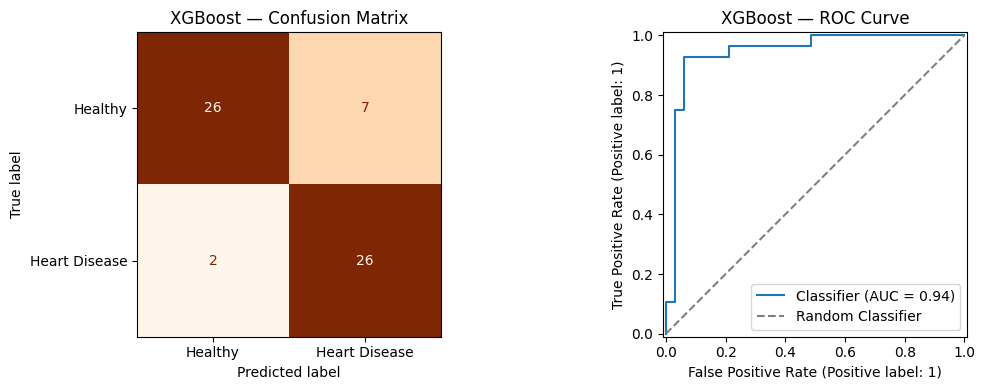

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(confusion_matrix=cm_xgb,
                       display_labels=['Healthy', 'Heart Disease']).plot(
    ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('XGBoost — Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_prob_xgb, ax=axes[1])
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Random Classifier')
axes[1].set_title('XGBoost — ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7.3 Train LightGBM

In [53]:
lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgbm_model.fit(X_train, y_train)
print('LightGBM trained successfully ✅')

LightGBM trained successfully ✅


## 7.4 Evaluate LightGBM

In [54]:
y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
roc_auc_lgbm  = roc_auc_score(y_test, y_prob_lgbm)

print(f'✅ Accuracy:  {accuracy_lgbm * 100:.2f}%')
print(f'✅ ROC-AUC:   {roc_auc_lgbm:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_lgbm, target_names=['Healthy', 'Heart Disease']))

✅ Accuracy:  83.61%
✅ ROC-AUC:   0.9524

Classification Report:
               precision    recall  f1-score   support

      Healthy       0.93      0.76      0.83        33
Heart Disease       0.76      0.93      0.84        28

     accuracy                           0.84        61
    macro avg       0.85      0.84      0.84        61
 weighted avg       0.85      0.84      0.84        61



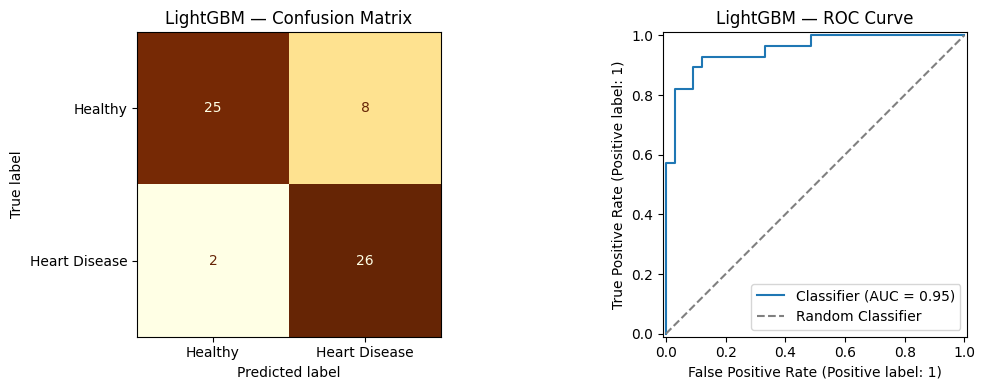

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
ConfusionMatrixDisplay(confusion_matrix=cm_lgbm,
                       display_labels=['Healthy', 'Heart Disease']).plot(
    ax=axes[0], colorbar=False, cmap='YlOrBr')
axes[0].set_title('LightGBM — Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_prob_lgbm, ax=axes[1])
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Random Classifier')
axes[1].set_title('LightGBM — ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7.5 Feature Importance Comparison

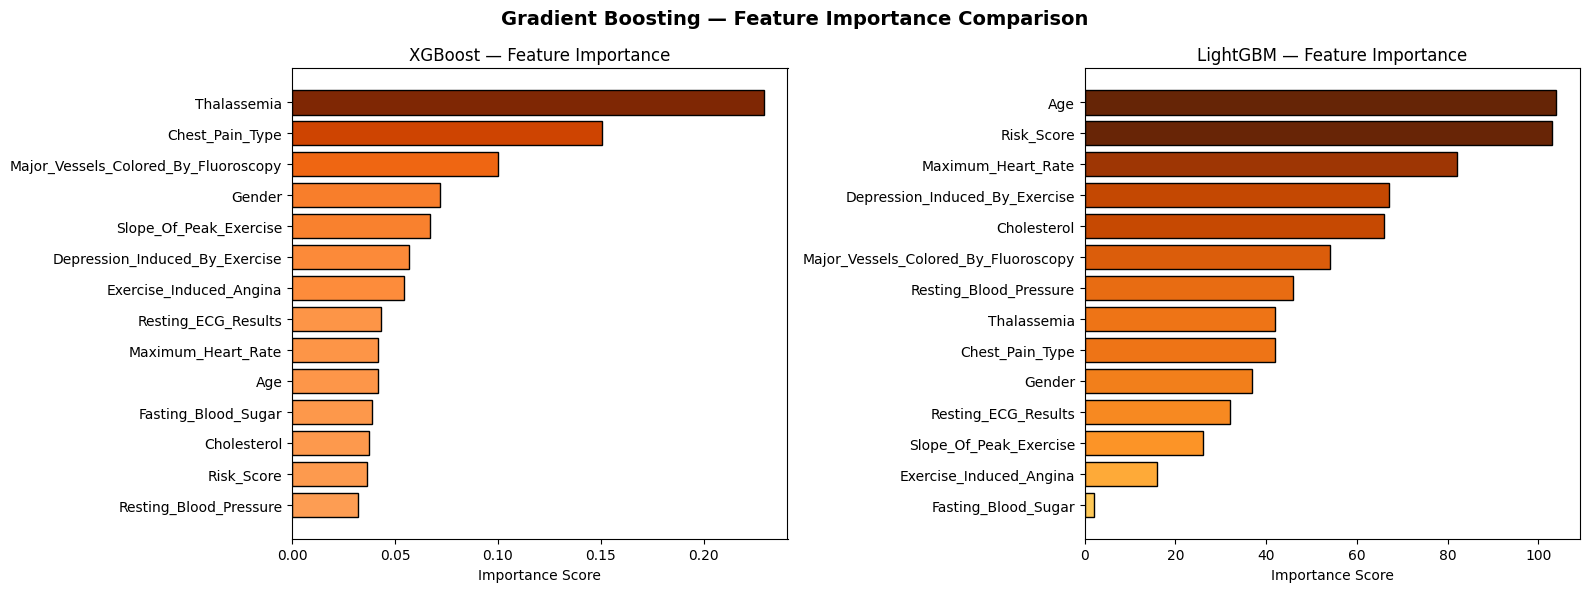

In [56]:
xgb_imp  = pd.Series(xgb_model.feature_importances_,  index=FEATURES).sort_values(ascending=False)
lgbm_imp = pd.Series(lgbm_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

xgb_colors = plt.cm.Oranges(0.35 + 0.65 * xgb_imp.values / xgb_imp.max())
axes[0].barh(xgb_imp.index, xgb_imp.values, color=xgb_colors, edgecolor='black')
axes[0].set_title('XGBoost — Feature Importance')
axes[0].set_xlabel('Importance Score')
axes[0].invert_yaxis()

lgbm_colors = plt.cm.YlOrBr(0.35 + 0.65 * lgbm_imp.values / lgbm_imp.max())
axes[1].barh(lgbm_imp.index, lgbm_imp.values, color=lgbm_colors, edgecolor='black')
axes[1].set_title('LightGBM — Feature Importance')
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

plt.suptitle('Gradient Boosting — Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7.6 Overfitting Check

XGBoost:
  Training Accuracy: 99.17%
  Testing  Accuracy: 85.25%
  ⚠️  Gap = 13.9% — may be overfitting

LightGBM:
  Training Accuracy: 99.59%
  Testing  Accuracy: 83.61%
  ⚠️  Gap = 16.0% — may be overfitting



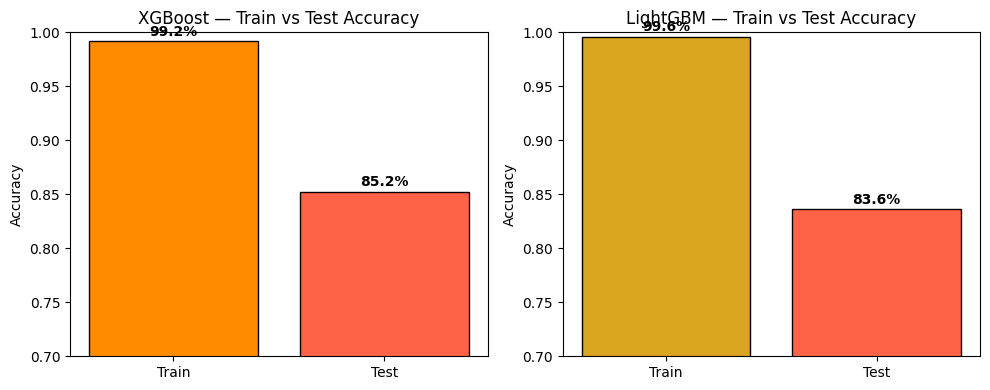

In [57]:
train_acc_xgb  = accuracy_score(y_train, xgb_model.predict(X_train))
train_acc_lgbm = accuracy_score(y_train, lgbm_model.predict(X_train))

for name, tr, te in [('XGBoost',  train_acc_xgb,  accuracy_xgb),
                     ('LightGBM', train_acc_lgbm, accuracy_lgbm)]:
    gap = abs(tr - te)
    status = '✅ Generalizes well' if gap < 0.05 else f'⚠️  Gap = {gap*100:.1f}% — may be overfitting'
    print(f'{name}:')
    print(f'  Training Accuracy: {tr * 100:.2f}%')
    print(f'  Testing  Accuracy: {te * 100:.2f}%')
    print(f'  {status}')
    print()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name, tr, te, color in [
    (axes[0], 'XGBoost',  train_acc_xgb,  accuracy_xgb,  'darkorange'),
    (axes[1], 'LightGBM', train_acc_lgbm, accuracy_lgbm, 'goldenrod'),
]:
    ax.bar(['Train', 'Test'], [tr, te], color=[color, 'tomato'], edgecolor='black')
    ax.set_ylim(0.7, 1.0)
    ax.set_title(f'{name} — Train vs Test Accuracy')
    ax.set_ylabel('Accuracy')
    for i, v in enumerate([tr, te]):
        ax.text(i, v + 0.005, f'{v*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 7.7 Summary

| Metric | XGBoost | LightGBM |
|---|---|---|
| Features used | 14 | 14 |
| Train / Test split | 80% / 20% | 80% / 20% |
| Preprocessing | Median imputation (**no scaling**) | Same |
| n_estimators | 100 | 100 |
| max_depth | 4 | 4 |
| learning_rate | 0.1 | 0.1 |
| Test Accuracy | *(run to see)* | *(run to see)* |
| ROC-AUC | *(run to see)* | *(run to see)* |

---
# Part 8 — Model Comparison

All five models evaluated on the same held-out test set.

In [58]:
model_results = {
    'Logistic\nRegression': {
        'accuracy': accuracy_score(y_test, model.predict(X_test_scaled)),
        'roc_auc' : roc_auc_score(y_test,  model.predict_proba(X_test_scaled)[:, 1]),
        'color'   : 'steelblue'
    },
    'Random\nForest': {
        'accuracy': accuracy_rf,
        'roc_auc' : roc_auc_rf,
        'color'   : 'forestgreen'
    },
    'SVM\n(RBF)': {
        'accuracy': accuracy_svm,
        'roc_auc' : roc_auc_svm,
        'color'   : 'mediumpurple'
    },
    'XGBoost': {
        'accuracy': accuracy_xgb,
        'roc_auc' : roc_auc_xgb,
        'color'   : 'darkorange'
    },
    'LightGBM': {
        'accuracy': accuracy_lgbm,
        'roc_auc' : roc_auc_lgbm,
        'color'   : 'goldenrod'
    },
}

names      = list(model_results.keys())
accuracies = [model_results[m]['accuracy'] for m in names]
roc_aucs   = [model_results[m]['roc_auc']  for m in names]
colors     = [model_results[m]['color']    for m in names]

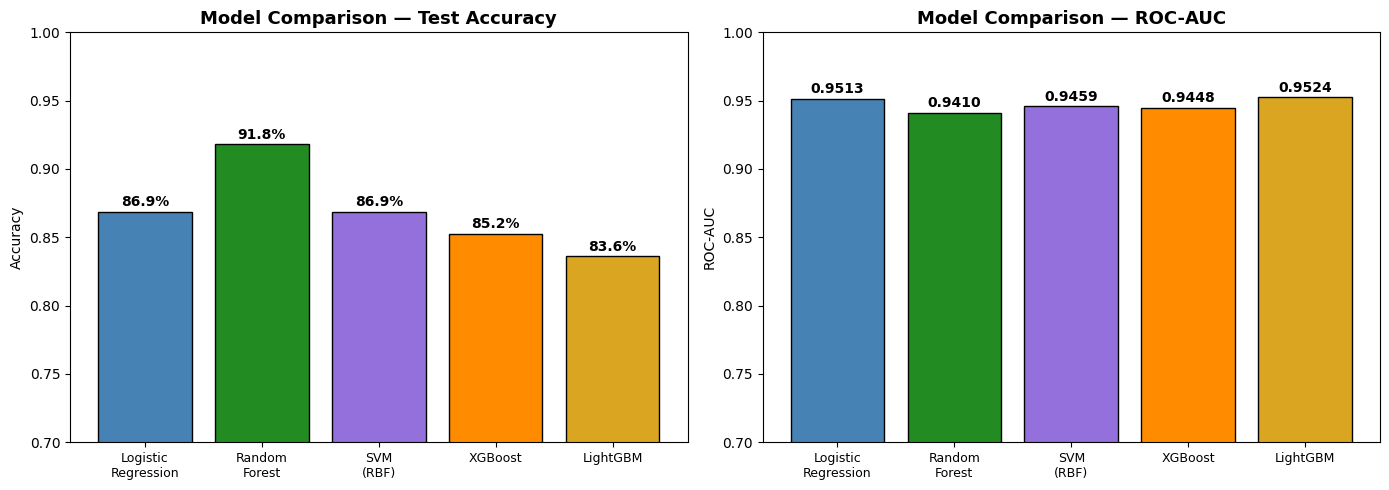

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, vals, title, ylabel, fmt in [
    (axes[0], accuracies, 'Model Comparison — Test Accuracy', 'Accuracy', lambda v: f'{v*100:.1f}%'),
    (axes[1], roc_aucs,   'Model Comparison — ROC-AUC',       'ROC-AUC',  lambda v: f'{v:.4f}'),
]:
    bars = ax.bar(names, vals, color=colors, edgecolor='black')
    ax.set_ylim(0.7, 1.0)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', labelsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.004,
                fmt(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

c:\Users\chhay\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\chhay\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\chhay\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\chhay\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curv

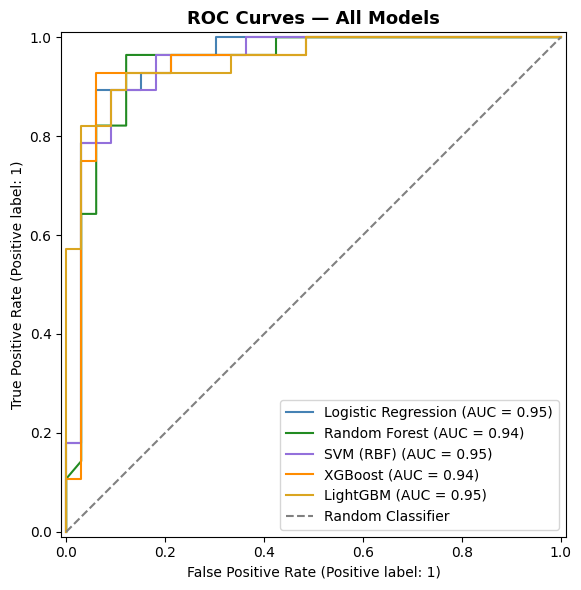

In [60]:
fig, ax = plt.subplots(figsize=(8, 6))

model_preds = [
    ('Logistic Regression', model.predict_proba(X_test_scaled)[:, 1], 'steelblue'),
    ('Random Forest',       y_prob_rf,                                 'forestgreen'),
    ('SVM (RBF)',           y_prob_svm,                                'mediumpurple'),
    ('XGBoost',             y_prob_xgb,                                'darkorange'),
    ('LightGBM',            y_prob_lgbm,                               'goldenrod'),
]
for name, yp, color in model_preds:
    RocCurveDisplay.from_predictions(y_test, yp, ax=ax, name=name, color=color)

ax.plot([0, 1], [0, 1], '--', color='gray', label='Random Classifier')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [61]:
clean_names = [n.replace('\n', ' ') for n in names]

comparison_df = pd.DataFrame({
    'Model'    : clean_names,
    'Accuracy' : [f'{v*100:.2f}%' for v in accuracies],
    'ROC-AUC'  : [f'{v:.4f}'      for v in roc_aucs],
    'Scaling'  : ['Required', 'Not required', 'Required', 'Not required', 'Not required'],
    'Type'     : ['Linear', 'Bagging Ensemble', 'Kernel Method',
                  'Boosting Ensemble', 'Boosting Ensemble'],
})

print('=' * 80)
print(comparison_df.to_string(index=False))
print('=' * 80)
print()

best_acc = max(zip(accuracies, clean_names))
best_auc = max(zip(roc_aucs,   clean_names))
print(f'🏆 Best Accuracy : {best_acc[1]} ({best_acc[0]*100:.2f}%)')
print(f'🏆 Best ROC-AUC  : {best_auc[1]} ({best_auc[0]:.4f})')

              Model Accuracy ROC-AUC      Scaling              Type
Logistic Regression   86.89%  0.9513     Required            Linear
      Random Forest   91.80%  0.9410 Not required  Bagging Ensemble
          SVM (RBF)   86.89%  0.9459     Required     Kernel Method
            XGBoost   85.25%  0.9448 Not required Boosting Ensemble
           LightGBM   83.61%  0.9524 Not required Boosting Ensemble

🏆 Best Accuracy : Random Forest (91.80%)
🏆 Best ROC-AUC  : LightGBM (0.9524)


## Final Summary

| Model | Feature Scaling | Feature Importance Method | Best For |
|---|---|---|---|
| Logistic Regression | ✅ Required | Coefficients (linear) | Interpretability, medical baseline |
| Random Forest | ❌ Not required | Gini impurity | Robust, non-linear, handles outliers |
| SVM (RBF) | ✅ Required | Permutation Importance | Small datasets, non-linear boundaries |
| XGBoost | ❌ Not required | Gain / weight | High accuracy, tabular data |
| LightGBM | ❌ Not required | Gain / weight | Fast training, large datasets |

---
# Part 9 — Save All Models

Persist every trained model with `joblib` and `pickle`

In [62]:
models_to_save = {
    'logistic_regression': model,
    'random_forest'      : rf_model,
    'svm'                : svm_model,
    'xgboost'            : xgb_model,
    'lightgbm'           : lgbm_model,
}

for name, m in models_to_save.items():
    joblib.dump(m, f'{name}_model.joblib')
    print(f'  Saved: {name}_model.joblib')

print('\nAll 5 models saved successfully ✅')

  Saved: logistic_regression_model.joblib
  Saved: random_forest_model.joblib
  Saved: svm_model.joblib
  Saved: xgboost_model.joblib
  Saved: lightgbm_model.joblib

All 5 models saved successfully ✅


In [63]:
# save the models as .pkl files 
import pickle
for name, m in models_to_save.items():
    with open(f'{name}_model.pkl', 'wb') as f:
        pickle.dump(m, f)
    print(f'  Saved: {name}_model.pkl')


  Saved: logistic_regression_model.pkl
  Saved: random_forest_model.pkl
  Saved: svm_model.pkl
  Saved: xgboost_model.pkl
  Saved: lightgbm_model.pkl
